Connected to .venv (3.12.0) (Python 3.12.0)

 # Fase 3 — Modelagem Não Supervisionada
 **TechChallenger3 — Previsão de Atrasos de Voos (EUA)**

 Objetivo: Agrupar aeroportos por perfil de atraso via KMeans + PCA
 e identificar companhias aéreas com padrões similares

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import folium
from folium.plugins import MarkerCluster

_ROOT  = Path(__file__).resolve().parent.parent
DADOS  = _ROOT / "dados"
FIGS   = _ROOT / "outputs" / "figures"
OUT    = _ROOT / "outputs"
FIGS.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (11, 5)})
sns.set_theme(style="whitegrid", palette="muted")

CLUSTER_COLORS = ["#2196F3", "#FF5722", "#4CAF50", "#9C27B0", "#FF9800"]

print("Bibliotecas carregadas.")

Bibliotecas carregadas.


 ---
 ## Seção 1 — Carregamento e Perfil por Aeroporto

In [ ]:
dtype_flights = {
    "YEAR": "int16", "MONTH": "int8", "DAY": "int8", "DAY_OF_WEEK": "int8",
    "AIRLINE": "category", "ORIGIN_AIRPORT": "category",
    "DESTINATION_AIRPORT": "category", "SCHEDULED_DEPARTURE": "int32",
    "DEPARTURE_DELAY": "float32", "TAXI_OUT": "float32",
    "SCHEDULED_TIME": "float32", "ELAPSED_TIME": "float32",
    "AIR_TIME": "float32", "DISTANCE": "float32",
    "TAXI_IN": "float32", "ARRIVAL_DELAY": "float32",
    "DIVERTED": "int8", "CANCELLED": "int8",
    "CANCELLATION_REASON": "category",
    "AIR_SYSTEM_DELAY": "float32", "SECURITY_DELAY": "float32",
    "AIRLINE_DELAY": "float32", "LATE_AIRCRAFT_DELAY": "float32",
    "WEATHER_DELAY": "float32",
}

flights  = pd.read_csv(DADOS / "flights.csv",  dtype=dtype_flights, low_memory=False)
airports = pd.read_csv(DADOS / "airports.csv")
airlines = pd.read_csv(DADOS / "airlines.csv")

print(f"flights : {flights.shape}")

flights : (5819079, 31)


In [ ]:
# Preencher colunas de delay: NaN = sem atraso
DELAY_COLS = ["AIR_SYSTEM_DELAY","SECURITY_DELAY","AIRLINE_DELAY",
              "LATE_AIRCRAFT_DELAY","WEATHER_DELAY"]
flights[DELAY_COLS] = flights[DELAY_COLS].fillna(0)

# Base de voos completados para métricas de delay
flights_ok = flights[(flights["CANCELLED"] == 0) & (flights["DIVERTED"] == 0)].copy()
flights_ok = flights_ok.dropna(subset=["ARRIVAL_DELAY", "DEPARTURE_DELAY"])

In [ ]:
# Agregar perfil por ORIGIN_AIRPORT
# Delay total por voo (para calcular proporção de cada causa)
flights_ok["TOTAL_DELAY"] = (
    flights_ok["AIR_SYSTEM_DELAY"] + flights_ok["SECURITY_DELAY"]
    + flights_ok["AIRLINE_DELAY"] + flights_ok["LATE_AIRCRAFT_DELAY"]
    + flights_ok["WEATHER_DELAY"]
)

def safe_rate(num, denom, fill=0.0):
    return np.where(denom > 0, num / denom, fill)

airport_profile = (
    flights_ok.groupby("ORIGIN_AIRPORT")
    .agg(
        total_flights      = ("ARRIVAL_DELAY", "count"),
        avg_departure_delay= ("DEPARTURE_DELAY", "mean"),
        avg_arrival_delay  = ("ARRIVAL_DELAY", "mean"),
        avg_distance       = ("DISTANCE", "mean"),
        avg_taxi_out       = ("TAXI_OUT", "mean"),
        pct_delayed_15     = ("ARRIVAL_DELAY", lambda x: (x > 15).mean() * 100),
        total_delay_min    = ("TOTAL_DELAY", "sum"),
        weather_delay_min  = ("WEATHER_DELAY", "sum"),
        airline_delay_min  = ("AIRLINE_DELAY", "sum"),
        late_ac_delay_min  = ("LATE_AIRCRAFT_DELAY", "sum"),
        system_delay_min   = ("AIR_SYSTEM_DELAY", "sum"),
    )
    .reset_index()
)

# Taxas de causa
airport_profile["weather_delay_rate"] = safe_rate(
    airport_profile["weather_delay_min"], airport_profile["total_delay_min"]) * 100
airport_profile["airline_delay_rate"] = safe_rate(
    airport_profile["airline_delay_min"], airport_profile["total_delay_min"]) * 100
airport_profile["late_ac_delay_rate"] = safe_rate(
    airport_profile["late_ac_delay_min"], airport_profile["total_delay_min"]) * 100
airport_profile["system_delay_rate"]  = safe_rate(
    airport_profile["system_delay_min"],  airport_profile["total_delay_min"]) * 100

# Taxa de cancelamento (do dataset completo)
cancel_rate = (
    flights.groupby("ORIGIN_AIRPORT")["CANCELLED"].mean() * 100
).reset_index().rename(columns={"CANCELLED": "cancellation_rate"})
airport_profile = airport_profile.merge(cancel_rate, on="ORIGIN_AIRPORT", how="left")

# Merge com informações geográficas
airport_profile = airport_profile.merge(
    airports[["IATA_CODE","AIRPORT","CITY","STATE","LATITUDE","LONGITUDE"]],
    left_on="ORIGIN_AIRPORT", right_on="IATA_CODE", how="left",
).drop(columns=["IATA_CODE"])

# Filtrar: aeroportos com volume mínimo de 500 voos
airport_profile = airport_profile[airport_profile["total_flights"] >= 500].copy()
airport_profile = airport_profile.dropna(subset=["LATITUDE","LONGITUDE"])

print(f"Aeroportos com perfil completo: {len(airport_profile)}")
print(airport_profile.describe().T[["mean","std","min","max"]].round(2))

Aeroportos com perfil completo: 293
                          mean        std      min         max
total_flights         17818.45   41318.17   517.00   343506.00
avg_departure_delay       7.10       3.55    -6.51       17.39
avg_arrival_delay         4.31       3.55    -6.62       16.15
avg_distance            519.40     294.62    56.46     1449.21
avg_taxi_out             13.89       2.76     6.80       27.00
pct_delayed_15           16.53       3.56     3.91       28.90
total_delay_min      202102.56  488891.88  1479.00  4177456.00
weather_delay_min     10193.29   36729.76     0.00   422593.00
airline_delay_min     64614.23  163670.59   146.00  1260840.00
late_ac_delay_min     80946.24  188451.80   650.00  1543993.00
system_delay_min      46088.28  108655.22   216.00   947333.00
weather_delay_rate        4.81       4.14     0.00       26.27
airline_delay_rate       29.26       9.04     4.07       57.97
late_ac_delay_rate       43.29      10.72    14.85       84.91
system_delay_rate  

 ---
 ## Seção 2 — Preparação das Features para Clustering

In [ ]:
CLUSTER_FEATURES = [
    "avg_arrival_delay",
    "avg_departure_delay",
    "pct_delayed_15",
    "cancellation_rate",
    "avg_taxi_out",
    "avg_distance",
    "weather_delay_rate",
    "airline_delay_rate",
    "late_ac_delay_rate",
    "system_delay_rate",
]

X_raw = airport_profile[CLUSTER_FEATURES].values

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Matrix de features: {X_scaled.shape}")
print(f"Features usadas: {CLUSTER_FEATURES}")

Matrix de features: (293, 10)
Features usadas: ['avg_arrival_delay', 'avg_departure_delay', 'pct_delayed_15', 'cancellation_rate', 'avg_taxi_out', 'avg_distance', 'weather_delay_rate', 'airline_delay_rate', 'late_ac_delay_rate', 'system_delay_rate']


 ---
 ## Seção 3 — KMeans: Elbow Method e Silhouette Score

In [ ]:
inertias    = []
silhouettes = []
K_RANGE     = range(2, 11)

print("Calculando Elbow e Silhouette para k=2..10...")
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=5000, random_state=42))
    print(f"  k={k}  inércia={km.inertia_:,.0f}  silhouette={silhouettes[-1]:.4f}")

Calculando Elbow e Silhouette para k=2..10...
  k=2  inércia=2,419  silhouette=0.1827
  k=3  inércia=2,148  silhouette=0.1887
  k=4  inércia=1,932  silhouette=0.1758
  k=5  inércia=1,766  silhouette=0.1554
  k=6  inércia=1,643  silhouette=0.1340
  k=7  inércia=1,539  silhouette=0.1330
  k=8  inércia=1,455  silhouette=0.1423
  k=9  inércia=1,401  silhouette=0.1348
  k=10  inércia=1,345  silhouette=0.1435


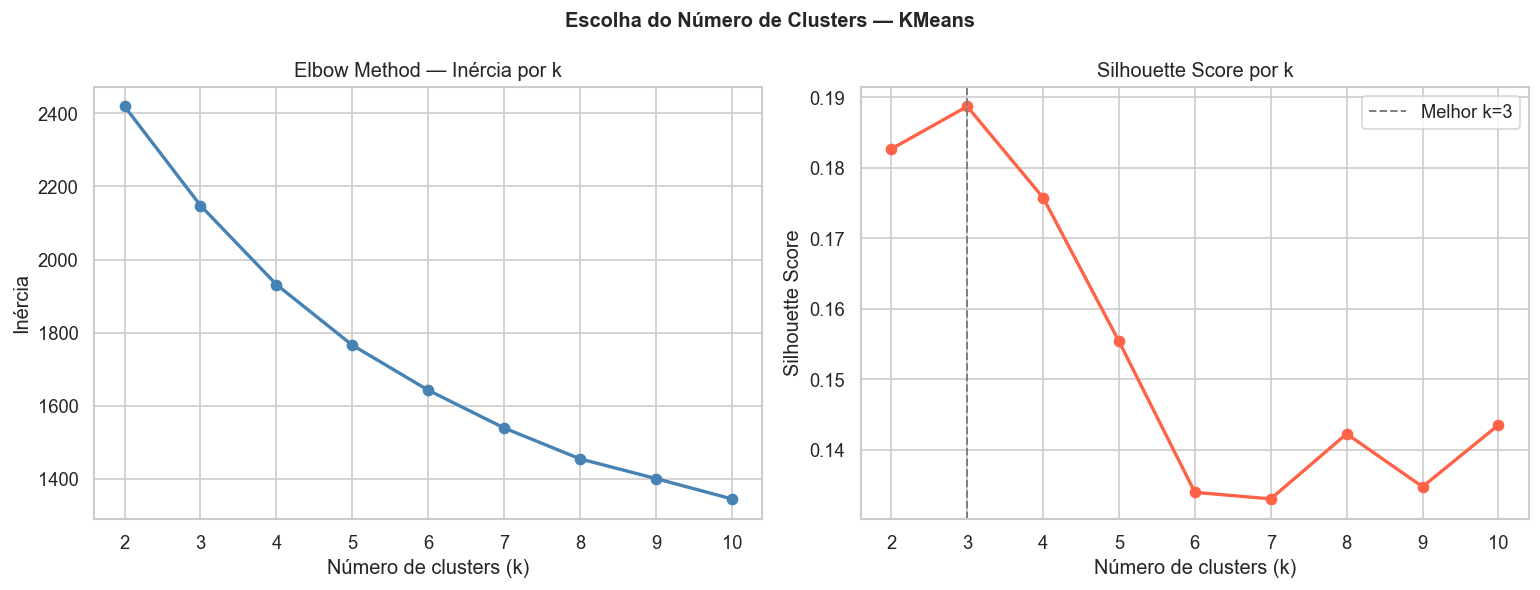


Melhor k pelo Silhouette Score: 3


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(K_RANGE), inertias, marker="o", color="steelblue", linewidth=2)
axes[0].set_title("Elbow Method — Inércia por k")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inércia")
axes[0].set_xticks(list(K_RANGE))

axes[1].plot(list(K_RANGE), silhouettes, marker="o", color="tomato", linewidth=2)
axes[1].set_title("Silhouette Score por k")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(list(K_RANGE))

best_k = int(np.argmax(silhouettes)) + 2  # K_RANGE começa em 2
axes[1].axvline(best_k, color="gray", linestyle="--", linewidth=1.2,
                label=f"Melhor k={best_k}")
axes[1].legend()

plt.suptitle("Escolha do Número de Clusters — KMeans", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS / "cluster_01_elbow_silhouette.png")
plt.show()
print(f"\nMelhor k pelo Silhouette Score: {best_k}")

 ---
 ## Seção 4 — KMeans Final e Interpretação dos Clusters

In [ ]:
K_FINAL = best_k
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
airport_profile["CLUSTER"] = km_final.fit_predict(X_scaled)

print(f"Distribuição dos clusters (k={K_FINAL}):")
print(airport_profile["CLUSTER"].value_counts().sort_index())

Distribuição dos clusters (k=3):
CLUSTER
0     61
1    165
2     67
Name: count, dtype: int64


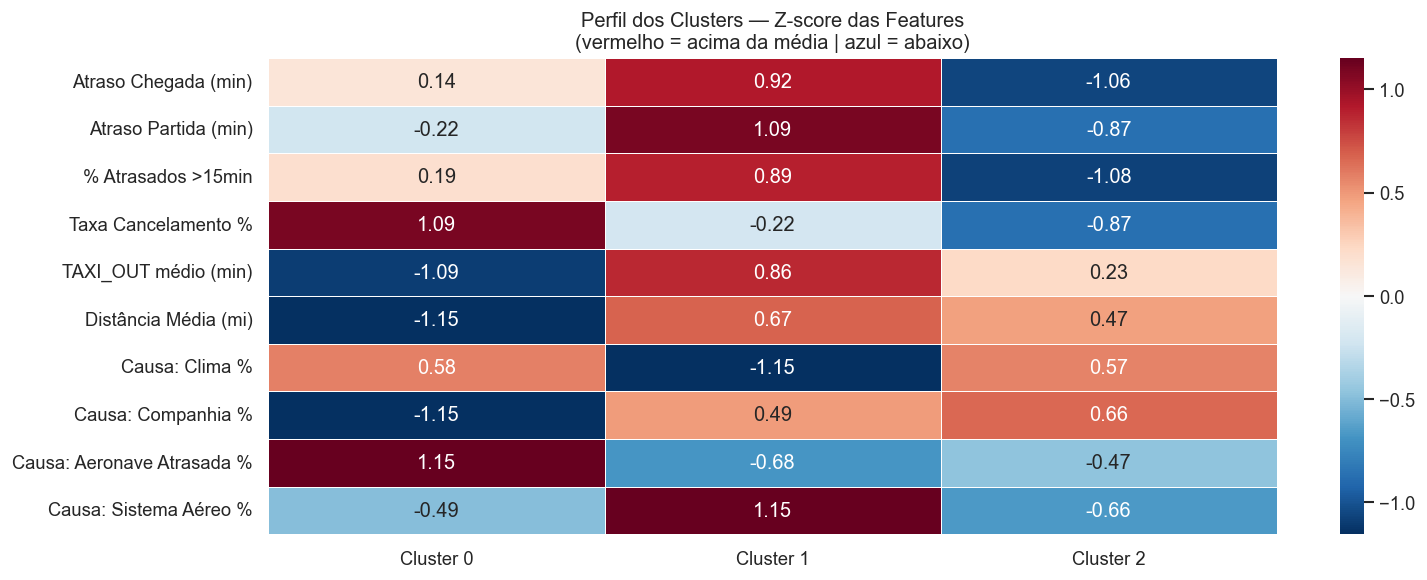

In [ ]:
# Heatmap: média das features por cluster (z-score para comparação justa)
cluster_means = (
    airport_profile.groupby("CLUSTER")[CLUSTER_FEATURES].mean()
)
cluster_means_z = (cluster_means - cluster_means.mean()) / cluster_means.std()

feature_labels = {
    "avg_arrival_delay":   "Atraso Chegada (min)",
    "avg_departure_delay": "Atraso Partida (min)",
    "pct_delayed_15":      "% Atrasados >15min",
    "cancellation_rate":   "Taxa Cancelamento %",
    "avg_taxi_out":        "TAXI_OUT médio (min)",
    "avg_distance":        "Distância Média (mi)",
    "weather_delay_rate":  "Causa: Clima %",
    "airline_delay_rate":  "Causa: Companhia %",
    "late_ac_delay_rate":  "Causa: Aeronave Atrasada %",
    "system_delay_rate":   "Causa: Sistema Aéreo %",
}
cluster_means_z.columns = [feature_labels[c] for c in cluster_means_z.columns]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(cluster_means_z.T, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax,
            xticklabels=[f"Cluster {i}" for i in cluster_means_z.index])
ax.set_title("Perfil dos Clusters — Z-score das Features\n(vermelho = acima da média | azul = abaixo)")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(FIGS / "cluster_02_cluster_heatmap.png")
plt.show()

In [ ]:
# Tabela de métricas absolutas por cluster
print("\n=== Métricas Absolutas por Cluster ===")
summary = cluster_means[["avg_arrival_delay","pct_delayed_15","cancellation_rate",
                          "avg_taxi_out","avg_distance","weather_delay_rate","airline_delay_rate"]]
summary.columns = ["Atraso Arr (min)", "% Atras. >15", "% Cancel.",
                   "Taxi Out (min)", "Distância (mi)", "Clima %", "Companhia %"]
print(summary.round(2).to_string())

# Tamanho dos clusters
size = airport_profile.groupby("CLUSTER").agg(
    n_aeroportos=("ORIGIN_AIRPORT","count"),
    exemplos=("ORIGIN_AIRPORT", lambda x: ", ".join(x.value_counts().head(4).index.astype(str)))
)
print("\n=== Tamanho e Exemplos de Aeroportos ===")
print(size.to_string())


=== Métricas Absolutas por Cluster ===
         Atraso Arr (min)  % Atras. >15  % Cancel.  Taxi Out (min)  Distância (mi)  Clima %  Companhia %
CLUSTER                                                                                                 
0                    3.84     16.190001       3.79           11.74      287.640015     5.78    20.820000
1                    6.14     18.469999       2.15           14.73      589.929993     4.06    31.180000
2                    0.25     12.060000       1.32           13.76      556.700012     5.77    32.220001

=== Tamanho e Exemplos de Aeroportos ===
         n_aeroportos            exemplos
CLUSTER                                  
0                  61  ABI, ACT, ACV, ALO
1                 165  ABE, ABQ, ABR, ABY
2                  67  ALB, ANC, BDL, BIL


 ---
 ## Seção 5 — PCA: Redução para 2D

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_explained = pca.explained_variance_ratio_ * 100
print(f"Variância explicada — PC1: {var_explained[0]:.1f}% | PC2: {var_explained[1]:.1f}% | Total: {sum(var_explained):.1f}%")

airport_profile["PC1"] = X_pca[:, 0]
airport_profile["PC2"] = X_pca[:, 1]

Variância explicada — PC1: 29.9% | PC2: 19.6% | Total: 49.5%


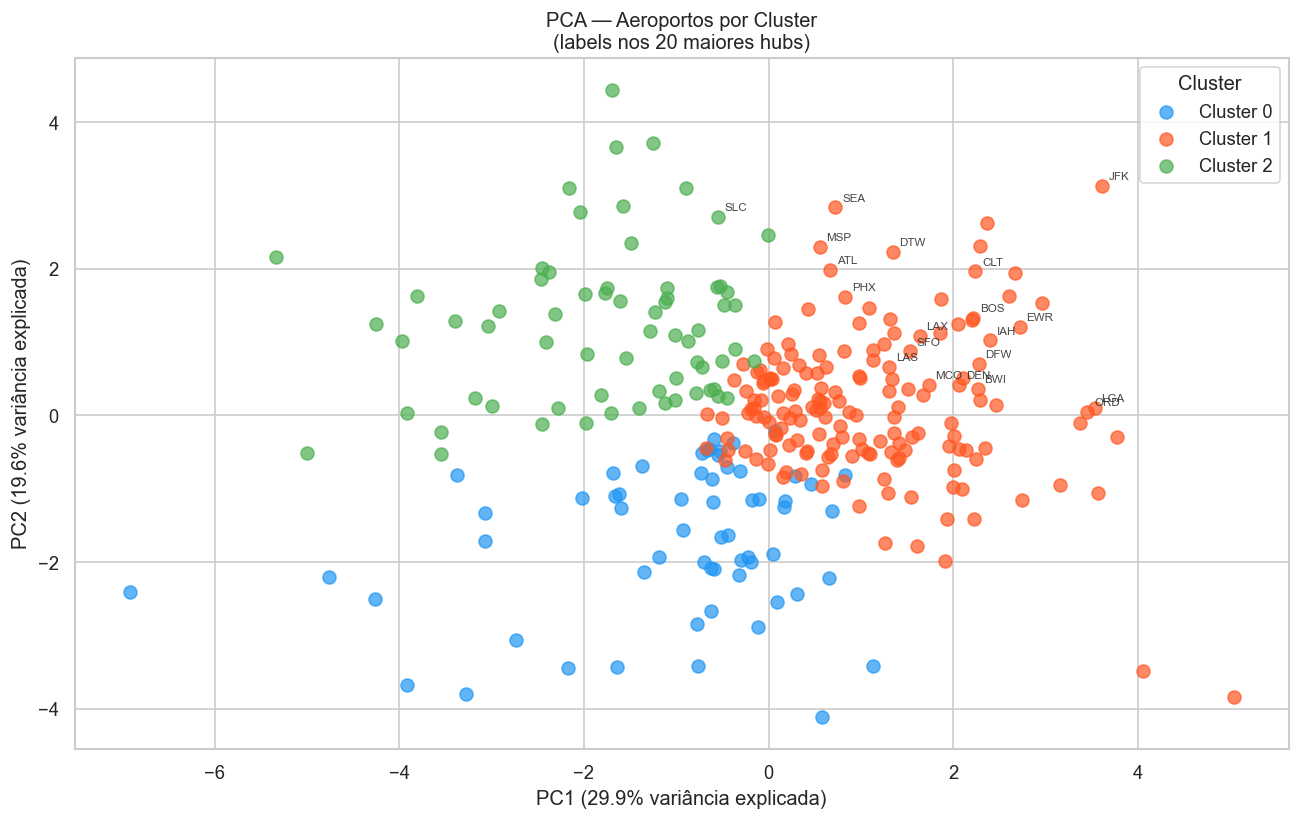

In [ ]:
# Scatter PCA colorido por cluster
fig, ax = plt.subplots(figsize=(11, 7))
for c in sorted(airport_profile["CLUSTER"].unique()):
    mask = airport_profile["CLUSTER"] == c
    ax.scatter(
        airport_profile.loc[mask, "PC1"],
        airport_profile.loc[mask, "PC2"],
        color=CLUSTER_COLORS[c], s=60, alpha=0.7, label=f"Cluster {c}",
    )

# Labels nos aeroportos mais relevantes (maiores volumes)
top_airports = airport_profile.nlargest(20, "total_flights")
for _, row in top_airports.iterrows():
    ax.annotate(str(row["ORIGIN_AIRPORT"]),
                (row["PC1"], row["PC2"]),
                fontsize=7, alpha=0.85,
                xytext=(4, 4), textcoords="offset points")

ax.set_xlabel(f"PC1 ({var_explained[0]:.1f}% variância explicada)")
ax.set_ylabel(f"PC2 ({var_explained[1]:.1f}% variância explicada)")
ax.set_title("PCA — Aeroportos por Cluster\n(labels nos 20 maiores hubs)")
ax.legend(title="Cluster")
plt.tight_layout()
plt.savefig(FIGS / "cluster_03_pca_scatter.png")
plt.show()

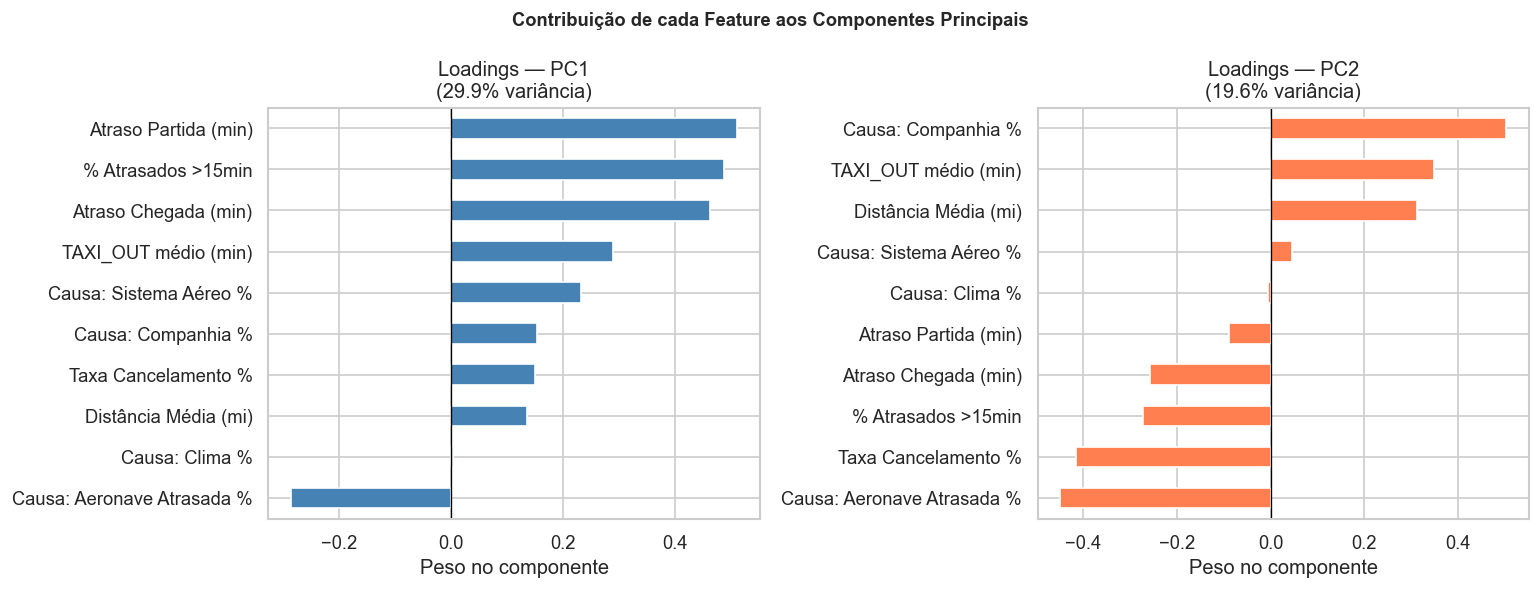

In [ ]:
# Loadings do PCA — contribuição de cada feature aos componentes principais
loadings = pd.DataFrame(
    pca.components_.T,
    index=[feature_labels[f] for f in CLUSTER_FEATURES],
    columns=["PC1", "PC2"],
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, color in [(axes[0], "PC1", "steelblue"), (axes[1], "PC2", "coral")]:
    loadings[col].sort_values().plot(kind="barh", ax=ax, color=color)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Loadings — {col}\n({var_explained[['PC1','PC2'].index(col)]:.1f}% variância)")
    ax.set_xlabel("Peso no componente")
plt.suptitle("Contribuição de cada Feature aos Componentes Principais", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS / "cluster_04_pca_loadings.png")
plt.show()

 ---
 ## Seção 6 — Mapa Geográfico dos Clusters

In [ ]:
# Mapa Folium interativo — salvo em HTML
m = folium.Map(location=[39.5, -98.35], zoom_start=4, tiles="CartoDB positron")

cluster_names_map = {i: f"Cluster {i}" for i in range(K_FINAL)}

for _, row in airport_profile.iterrows():
    c      = int(row["CLUSTER"])
    color  = CLUSTER_COLORS[c]
    popup_text = (
        f"<b>{row['ORIGIN_AIRPORT']}</b> — {row.get('AIRPORT','')}<br>"
        f"Cluster {c}<br>"
        f"Atraso médio: {row['avg_arrival_delay']:.1f} min<br>"
        f"% atrasados: {row['pct_delayed_15']:.1f}%<br>"
        f"Total voos: {int(row['total_flights']):,}"
    )
    folium.CircleMarker(
        location=[row["LATITUDE"], row["LONGITUDE"]],
        radius=max(4, min(14, row["total_flights"] / 50_000)),
        color=color, fill=True, fill_color=color, fill_opacity=0.75,
        popup=folium.Popup(popup_text, max_width=220),
        tooltip=f"{row['ORIGIN_AIRPORT']} (C{c})",
    ).add_to(m)

# Legenda manual
legend_html = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
            background:white;padding:10px;border-radius:6px;
            border:1px solid #ccc;font-size:13px;">
  <b>Clusters</b><br>
"""
for i in range(K_FINAL):
    legend_html += f'<span style="color:{CLUSTER_COLORS[i]};">&#9679;</span> Cluster {i}<br>'
legend_html += "</div>"
m.get_root().html.add_child(folium.Element(legend_html))

map_path = OUT / "cluster_mapa_aeroportos.html"
m.save(str(map_path))
print(f"Mapa interativo salvo: {map_path}")

Mapa interativo salvo: /Users/carpinterlouzada/repo/TechChallenger3/outputs/cluster_mapa_aeroportos.html


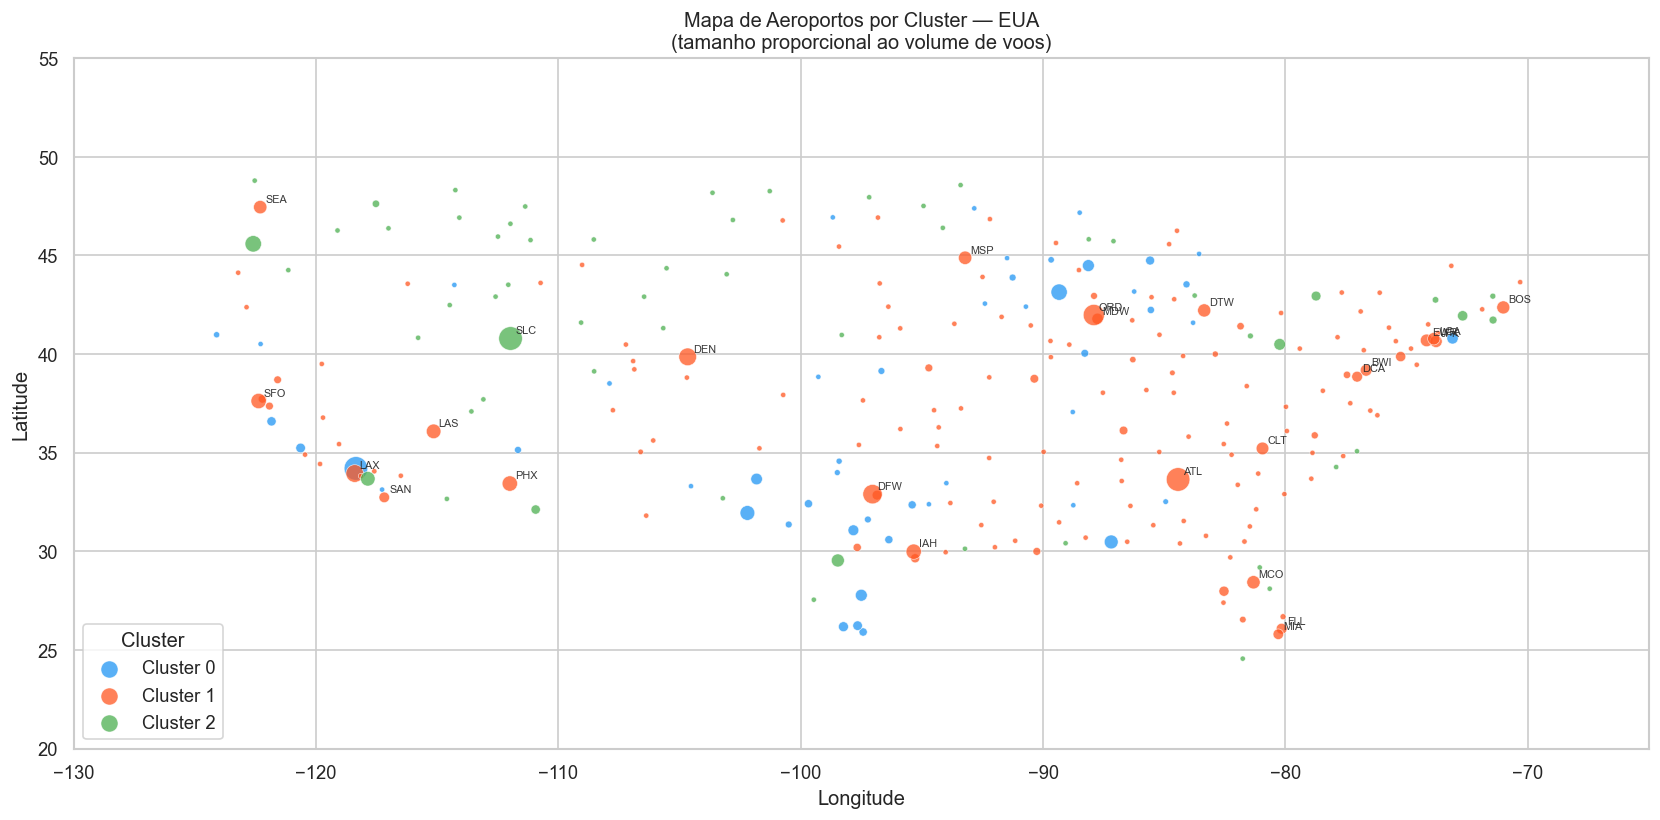

In [ ]:
# Versão estática do mapa (matplotlib) para o relatório
fig, ax = plt.subplots(figsize=(14, 7))
for c in sorted(airport_profile["CLUSTER"].unique()):
    mask = airport_profile["CLUSTER"] == c
    subset = airport_profile[mask]
    sizes  = (subset["total_flights"] / subset["total_flights"].max() * 200).clip(10, 200)
    ax.scatter(
        subset["LONGITUDE"], subset["LATITUDE"],
        c=CLUSTER_COLORS[c], s=sizes, alpha=0.75, label=f"Cluster {c}",
        edgecolors="white", linewidth=0.4,
    )

# Labels dos maiores hubs
for _, row in airport_profile.nlargest(25, "total_flights").iterrows():
    ax.annotate(str(row["ORIGIN_AIRPORT"]),
                (row["LONGITUDE"], row["LATITUDE"]),
                fontsize=6.5, alpha=0.9,
                xytext=(3, 3), textcoords="offset points")

ax.set_xlim(-130, -65)
ax.set_ylim(20, 55)
ax.set_title("Mapa de Aeroportos por Cluster — EUA\n(tamanho proporcional ao volume de voos)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(title="Cluster", loc="lower left")
plt.tight_layout()
plt.savefig(FIGS / "cluster_05_mapa_estatico.png")
plt.show()

 ---
 ## Seção 7 — Análise Adicional: Clustering de Companhias Aéreas

In [ ]:
airline_map = airlines.set_index("IATA_CODE")["AIRLINE"].to_dict()

airline_profile = (
    flights_ok.groupby("AIRLINE")
    .agg(
        total_flights      = ("ARRIVAL_DELAY", "count"),
        avg_arrival_delay  = ("ARRIVAL_DELAY", "mean"),
        avg_departure_delay= ("DEPARTURE_DELAY", "mean"),
        pct_delayed_15     = ("ARRIVAL_DELAY", lambda x: (x > 15).mean() * 100),
        avg_distance       = ("DISTANCE", "mean"),
        weather_rate       = ("WEATHER_DELAY",      lambda x: x.mean()),
        airline_rate       = ("AIRLINE_DELAY",       lambda x: x.mean()),
        late_ac_rate       = ("LATE_AIRCRAFT_DELAY", lambda x: x.mean()),
        system_rate        = ("AIR_SYSTEM_DELAY",    lambda x: x.mean()),
    )
    .reset_index()
)
airline_profile["AIRLINE_NAME"] = airline_profile["AIRLINE"].astype(str).map(airline_map)

cancel_al = (
    flights.groupby("AIRLINE")["CANCELLED"].mean() * 100
).reset_index().rename(columns={"CANCELLED": "cancellation_rate"})
airline_profile = airline_profile.merge(cancel_al, on="AIRLINE", how="left")

AL_FEATURES = ["avg_arrival_delay","pct_delayed_15","cancellation_rate",
               "avg_distance","weather_rate","airline_rate","late_ac_rate","system_rate"]

X_al = StandardScaler().fit_transform(airline_profile[AL_FEATURES].values)

# Silhouette para k=2..5 (apenas 14 airlines)
sil_al = []
for k in range(2, 6):
    km_al = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl   = km_al.fit_predict(X_al)
    sil_al.append(silhouette_score(X_al, lbl))
    print(f"  Airlines k={k}  silhouette={sil_al[-1]:.4f}")

best_k_al = int(np.argmax(sil_al)) + 2
print(f"\nMelhor k para airlines: {best_k_al}")

km_al_final = KMeans(n_clusters=best_k_al, random_state=42, n_init=20)
airline_profile["CLUSTER"] = km_al_final.fit_predict(X_al)

  Airlines k=2  silhouette=0.2270
  Airlines k=3  silhouette=0.2895
  Airlines k=4  silhouette=0.3038
  Airlines k=5  silhouette=0.2640

Melhor k para airlines: 4


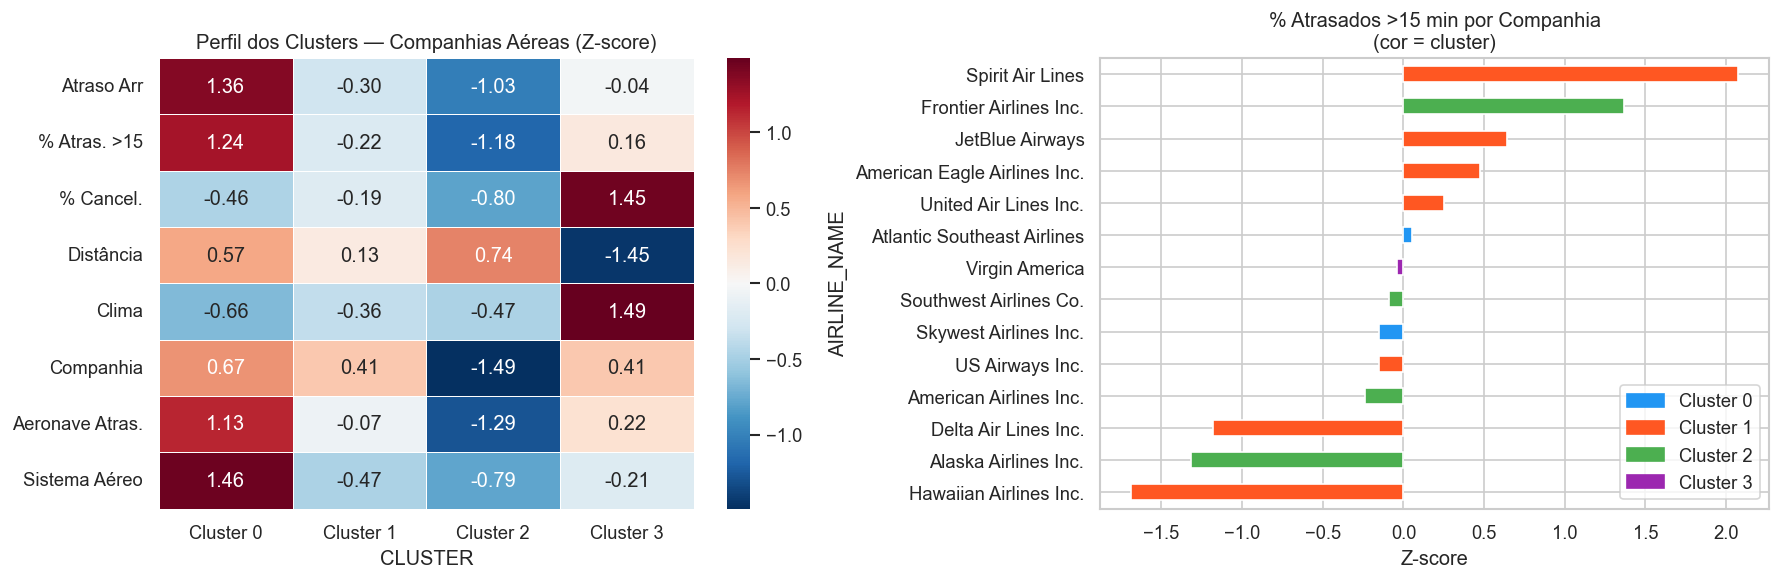

In [ ]:
# Heatmap de companhias por cluster
al_means = airline_profile.groupby("CLUSTER")[AL_FEATURES].mean()
al_means_z = (al_means - al_means.mean()) / al_means.std()
al_means_z.columns = ["Atraso Arr", "% Atras. >15", "% Cancel.",
                       "Distância", "Clima", "Companhia", "Aeronave Atras.", "Sistema Aéreo"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(al_means_z.T, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, ax=axes[0],
            xticklabels=[f"Cluster {i}" for i in al_means_z.index])
axes[0].set_title("Perfil dos Clusters — Companhias Aéreas (Z-score)")

al_plot = airline_profile[["AIRLINE_NAME","CLUSTER"] + AL_FEATURES[:4]].set_index("AIRLINE_NAME")
al_plot_z = (al_plot[AL_FEATURES[:4]] - al_plot[AL_FEATURES[:4]].mean()) / al_plot[AL_FEATURES[:4]].std()
colors_al = [CLUSTER_COLORS[c] for c in airline_profile.set_index("AIRLINE_NAME").loc[al_plot_z.index, "CLUSTER"]]
al_plot_z["pct_delayed_15"].sort_values().plot(kind="barh", ax=axes[1], color=colors_al)
axes[1].set_title("% Atrasados >15 min por Companhia\n(cor = cluster)")
axes[1].set_xlabel("Z-score")

# Legenda
patches = [mpatches.Patch(color=CLUSTER_COLORS[i], label=f"Cluster {i}")
           for i in range(best_k_al)]
axes[1].legend(handles=patches, loc="lower right")

plt.tight_layout()
plt.savefig(FIGS / "cluster_06_airline_clusters.png")
plt.show()

 ---
 ## Seção 8 — DBSCAN: Detecção de Aeroportos Anômalos

In [ ]:
# DBSCAN no espaço PCA 2D para identificar outliers
db = DBSCAN(eps=0.8, min_samples=3)
db_labels = db.fit_predict(X_pca)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise       = (db_labels == -1).sum()
print(f"DBSCAN → {n_clusters_db} clusters + {n_noise} aeroportos anômalos (label=-1)")

airport_profile["DBSCAN_LABEL"] = db_labels
anomalos = airport_profile[airport_profile["DBSCAN_LABEL"] == -1][
    ["ORIGIN_AIRPORT","CITY","STATE","avg_arrival_delay","pct_delayed_15","total_flights"]
].sort_values("avg_arrival_delay", ascending=False)

print("\n=== Aeroportos Anômalos (DBSCAN) ===")
print(anomalos.to_string(index=False))

DBSCAN → 2 clusters + 12 aeroportos anômalos (label=-1)

=== Aeroportos Anômalos (DBSCAN) ===
ORIGIN_AIRPORT                 CITY STATE  avg_arrival_delay  pct_delayed_15  total_flights
           BPT Beaumont/Port Arthur    TX          16.154696       24.972376            905
           ASE                Aspen    CO          15.492492       28.899786           3263
           ACV        Arcata/Eureka    CA           7.841483       22.397476           1268
           MKG             Muskegon    MI           6.600324       20.873787            618
           WRG             Wrangell    AK           4.667180       16.486902            649
           JFK             New York    NY           3.607519       21.413219          91663
           BRW               Barrow    AK           1.919708       15.085158            822
           SCC            Deadhorse    AK           1.099265       12.500000            816
           ITO                 Hilo    HI           0.343203        8.163980  

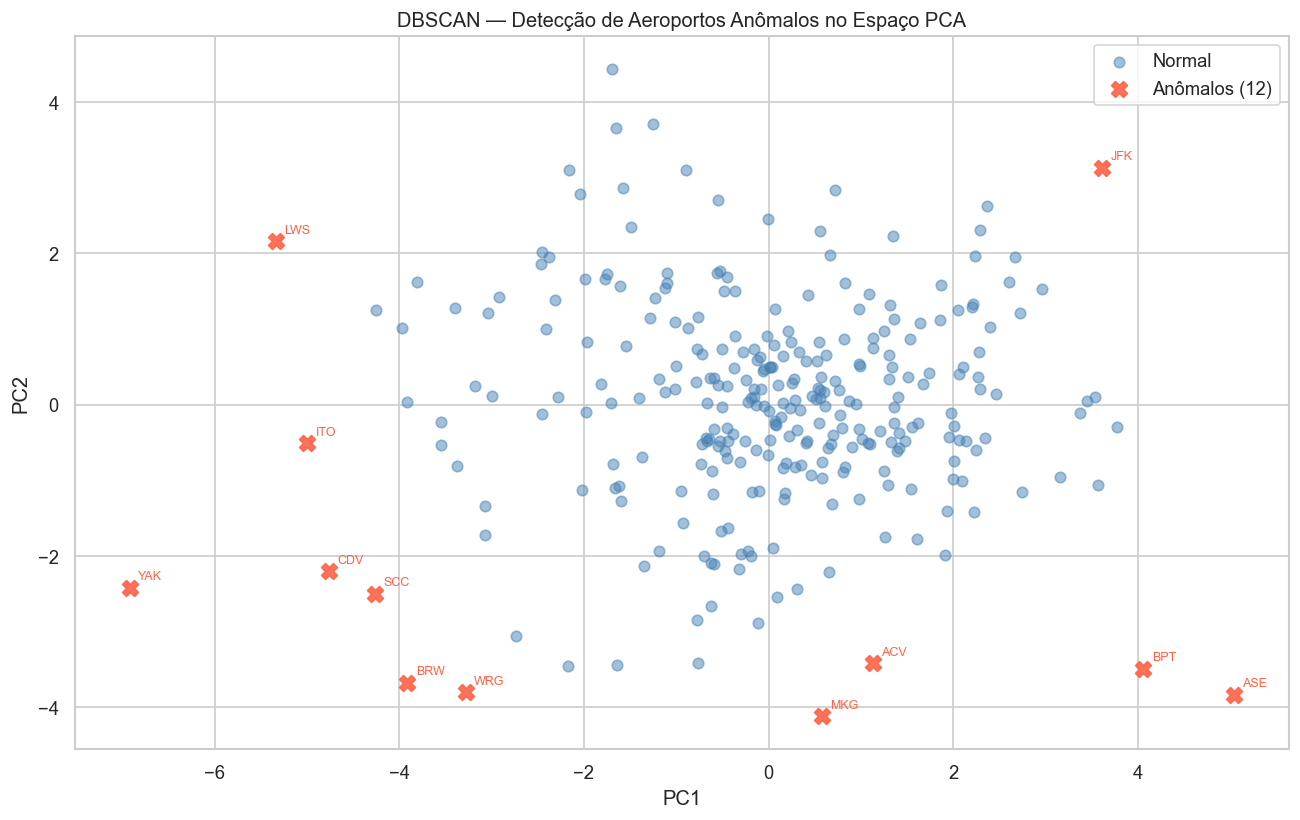

In [ ]:
fig, ax = plt.subplots(figsize=(11, 7))
normal_mask  = airport_profile["DBSCAN_LABEL"] >= 0
anomaly_mask = airport_profile["DBSCAN_LABEL"] == -1

ax.scatter(airport_profile.loc[normal_mask, "PC1"],
           airport_profile.loc[normal_mask, "PC2"],
           c="steelblue", s=40, alpha=0.5, label="Normal")
ax.scatter(airport_profile.loc[anomaly_mask, "PC1"],
           airport_profile.loc[anomaly_mask, "PC2"],
           c="tomato", s=90, marker="X", alpha=0.9, label=f"Anômalos ({n_noise})")

for _, row in airport_profile[anomaly_mask].iterrows():
    ax.annotate(str(row["ORIGIN_AIRPORT"]),
                (row["PC1"], row["PC2"]),
                fontsize=7.5, color="tomato",
                xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("DBSCAN — Detecção de Aeroportos Anômalos no Espaço PCA")
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / "cluster_07_dbscan_anomalies.png")
plt.show()

 ---
 ## Seção 9 — Exportar Resultados e Interpretação Final

In [ ]:
# Exportar CSV com clusters
output_cols = [
    "ORIGIN_AIRPORT","AIRPORT","CITY","STATE","LATITUDE","LONGITUDE",
    "CLUSTER","total_flights","avg_arrival_delay","avg_departure_delay",
    "pct_delayed_15","cancellation_rate","avg_taxi_out","avg_distance",
    "weather_delay_rate","airline_delay_rate","late_ac_delay_rate","system_delay_rate",
    "PC1","PC2",
]
airport_profile[output_cols].to_csv(OUT / "airport_clusters.csv", index=False)
print(f"Exportado: outputs/airport_clusters.csv  ({len(airport_profile)} aeroportos)")

# Salvar modelo KMeans e PCA para uso na Fase 4
MODELS = _ROOT / "outputs" / "models"
MODELS.mkdir(exist_ok=True)
joblib.dump(km_final, MODELS / "kmeans_airports.joblib")
joblib.dump(pca,      MODELS / "pca_airports.joblib")
joblib.dump(scaler,   MODELS / "scaler_airports.joblib")
print("Modelos KMeans, PCA e Scaler salvos em outputs/models/")

Exportado: outputs/airport_clusters.csv  (293 aeroportos)
Modelos KMeans, PCA e Scaler salvos em outputs/models/


 ---
 ## Seção 10 — Interpretação dos Clusters (Aeroportos)

 A interpretação abaixo é gerada após análise do heatmap Z-score e dos exemplos por cluster.
 **Ajuste as descrições conforme os valores reais obtidos ao rodar.**

In [ ]:
# Interpretação dinâmica baseada nos dados
print("\n" + "="*60)
print("INTERPRETAÇÃO DOS CLUSTERS DE AEROPORTOS")
print("="*60)

for c in sorted(airport_profile["CLUSTER"].unique()):
    subset = airport_profile[airport_profile["CLUSTER"] == c]
    top_ap = subset.nlargest(5, "total_flights")["ORIGIN_AIRPORT"].astype(str).tolist()
    avg_delay = subset["avg_arrival_delay"].mean()
    pct_del   = subset["pct_delayed_15"].mean()
    n_ap      = len(subset)
    main_cause = cluster_means.loc[c, ["weather_delay_rate","airline_delay_rate",
                                        "late_ac_delay_rate","system_delay_rate"]].idxmax()
    cause_label = {
        "weather_delay_rate": "Clima",
        "airline_delay_rate": "Companhia",
        "late_ac_delay_rate": "Aeronave Atrasada",
        "system_delay_rate":  "Sistema Aéreo",
    }.get(main_cause, main_cause)

    print(f"\nCluster {c} ({n_ap} aeroportos)")
    print(f"  Atraso médio  : {avg_delay:.1f} min")
    print(f"  % atrasados   : {pct_del:.1f}%")
    print(f"  Causa dominante: {cause_label}")
    print(f"  Exemplos      : {', '.join(top_ap)}")


INTERPRETAÇÃO DOS CLUSTERS DE AEROPORTOS

Cluster 0 (61 aeroportos)
  Atraso médio  : 3.8 min
  % atrasados   : 16.2%
  Causa dominante: Aeronave Atrasada
  Exemplos      : BUR, MSN, MAF, PNS, GRB

Cluster 1 (165 aeroportos)
  Atraso médio  : 6.1 min
  % atrasados   : 18.5%
  Causa dominante: Aeronave Atrasada
  Exemplos      : ATL, ORD, DFW, DEN, LAX

Cluster 2 (67 aeroportos)
  Atraso médio  : 0.3 min
  % atrasados   : 12.1%
  Causa dominante: Aeronave Atrasada
  Exemplos      : SLC, PDX, HNL, SNA, SAT


 ---
 ## Resumo Final

In [ ]:
print("\n=== Fase 3 concluída ===")
print(f"Clusters encontrados (KMeans) : {K_FINAL}")
print(f"Variância explicada pelo PCA  : {sum(var_explained):.1f}%")
print(f"Aeroportos anômalos (DBSCAN)  : {n_noise}")
print(f"Figuras salvas                : {len(list(FIGS.glob('cluster_*.png')))} em {FIGS}")
print(f"CSV exportado                 : {OUT / 'airport_clusters.csv'}")
print(f"Mapa interativo               : {map_path}")


=== Fase 3 concluída ===
Clusters encontrados (KMeans) : 3
Variância explicada pelo PCA  : 49.5%
Aeroportos anômalos (DBSCAN)  : 12
Figuras salvas                : 7 em /Users/carpinterlouzada/repo/TechChallenger3/outputs/figures
CSV exportado                 : /Users/carpinterlouzada/repo/TechChallenger3/outputs/airport_clusters.csv
Mapa interativo               : /Users/carpinterlouzada/repo/TechChallenger3/outputs/cluster_mapa_aeroportos.html
